In [1]:
import requests
import io
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def mineria_sistemas_exoplanetarios(tipo_espectral, masa_min, masa_max):
    """
    Busca sistemas exoplanetarios mediante filtros de tipo espectral y masa.
    Limpia duplicados estelares priorizando el paper más actual.
    """
    url_base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    
    query = f"""
    SELECT 
        hostname AS estrella, sy_pnum AS num_planetas, sy_dist AS distancia_pc, 
        st_spectype AS tipo_espectral, st_teff AS temp_estrella_k, 
        st_rad AS radio_estrella_sol, st_mass AS masa_estrella_sol, st_teff_reflink AS ref_estrella,
        pl_name AS nombre_planeta, pl_orbper AS periodo_dias, pl_orbsmax AS semi_eje_ua, 
        pl_rade AS radio_tierra, pl_bmasse AS masa_tierra, pl_bmassj AS masa_jupiter, 
        pl_msinie AS mpsini_tierra, pl_msinij AS mpsini_jupiter, 
        discoverymethod AS metodo_descubrimiento, pl_orbper_reflink AS ref_planeta
    FROM pscomppars
    WHERE sy_pnum BETWEEN 2 AND 8
      AND st_spectype LIKE '%{tipo_espectral}%'
      AND (
          (pl_bmassj >= {masa_min} AND pl_bmassj <= {masa_max}) OR 
          (pl_msinij >= {masa_min} AND pl_msinij <= {masa_max})
      )
    ORDER BY sy_dist ASC
    """
    
    respuesta = requests.get(url_base, params={"query": query, "format": "csv"})
    if respuesta.status_code != 200: return None, None
    
    df = pd.read_csv(io.StringIO(respuesta.text))
    if df.empty: return None, None
            
    # 1. TABLA ESTRELLA (Única por estrella, la más actual)
    df_star = df[['estrella', 'num_planetas', 'distancia_pc', 'tipo_espectral', 'temp_estrella_k', 'radio_estrella_sol', 'masa_estrella_sol', 'ref_estrella']].copy()
    df_star['Año_Ref'] = df_star['ref_estrella'].str.extract(r'(\d{4})').astype(float)
    df_star = df_star.sort_values(by=['estrella', 'Año_Ref'], ascending=[True, False]).drop_duplicates(subset=['estrella'], keep='first')
    df_star = df_star.drop(columns=['Año_Ref']).reset_index(drop=True)
    df_star.columns = ['Estrella', 'Planetas_en_Sistema', 'Distancia(pc)', 'Tipo_Espectral', 'Temp_K', 'Radio_Sol', 'Masa_Sol', 'Ref_Estrella']
    
    # 2. TABLA PLANETAS
    df_planets = df[['estrella', 'nombre_planeta', 'periodo_dias', 'semi_eje_ua', 'masa_jupiter', 'mpsini_jupiter', 'masa_tierra', 'mpsini_tierra', 'radio_tierra', 'metodo_descubrimiento', 'ref_planeta']].reset_index(drop=True)
    df_planets.columns = ['Estrella', 'Planeta', 'Periodo(Dias)', 'Semi_Eje(UA)', 'Masa(Jup)', 'Mp_sin_i(Jup)', 'Masa(Tierra)', 'Mp_sin_i(Tierra)', 'Radio(Tierra)', 'Metodo', 'Referencia']
    
    return df_star, df_planets

In [3]:
def generar_reporte_y_graficos(df_star, df_planets, filtro_espectral, masa_min, masa_max):
    # Gráfico
    dist = df_star['Planetas_en_Sistema'].value_counts().sort_index()
    dist.plot(kind='bar', color='midnightblue', edgecolor='black', figsize=(8, 5))
    plt.title(f'Sistemas con {filtro_espectral} ({masa_min}-{masa_max} MJ)')
    plt.savefig(f'distribucion_{filtro_espectral}.png', dpi=300)
    plt.show()

    # Exportación
    nombre_base = f"Sistemas_{filtro_espectral}_{masa_min}a{masa_max}MJ"
    
    # LaTeX (reemplazamos espacios por guiones bajos para LaTeX pero sin arruinar los encabezados)
    latex_star = df_star.style.format(na_rep='--').to_latex(hrules=True)
    latex_planets = df_planets.style.format(na_rep='--').to_latex(hrules=True)
    
    with open(f"tabla_estrella_{nombre_base}.tex", "w", encoding='utf-8') as f: f.write(latex_star)
    with open(f"tabla_planetas_{nombre_base}.tex", "w", encoding='utf-8') as f: f.write(latex_planets)
    
    # TXT
    with open(f"Datos_{nombre_base}.txt", "w", encoding='utf-8') as f:
        f.write(df_star.to_string(index=False) + "\n\n" + df_planets.to_string(index=False))
        
    print(f"✅ Reporte completo generado.")

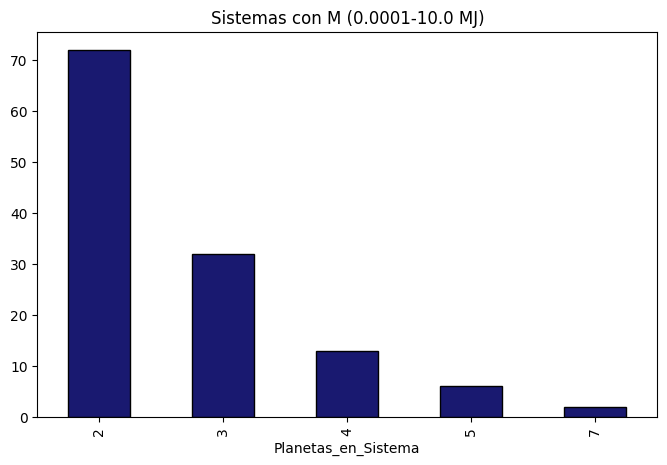

✅ Reporte completo generado.


In [4]:
if __name__ == "__main__":
    espectro = "M"
    m_min, m_max = 0.0001, 10.0
    
    star, planets = mineria_sistemas_exoplanetarios(espectro, m_min, m_max)
    if star is not None:
        generar_reporte_y_graficos(star, planets, espectro, m_min, m_max)